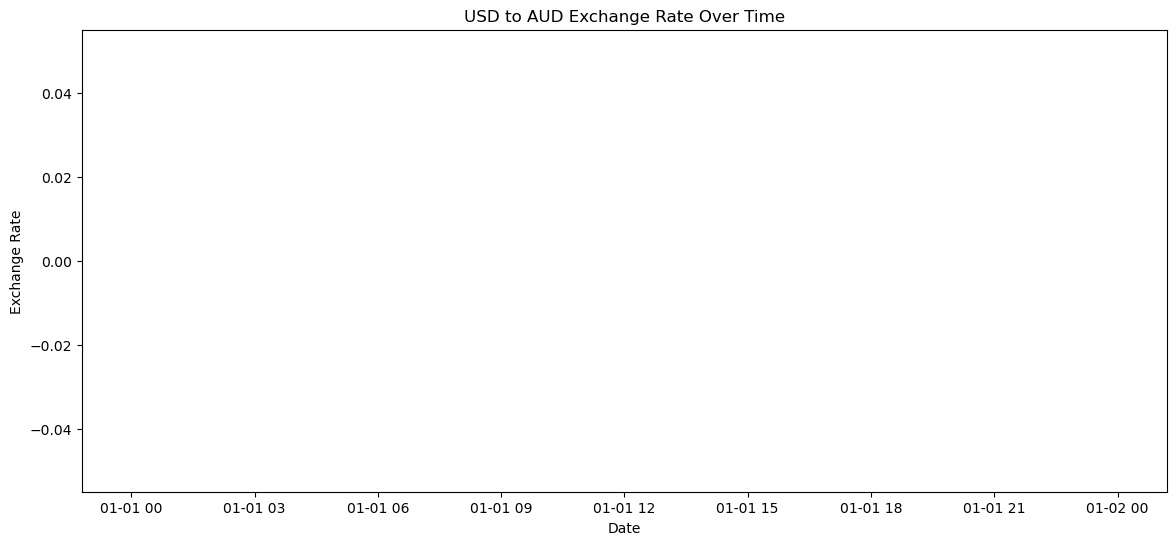

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Read as space-delimited (since original file does not have headers, and is not CSV)
df = pd.read_csv('exchange_rate.csv', sep='\s+', header=None, names=['date', 'exrate'], engine='python')

# Remove any non-date lines or columns; force the date column to str and filter out bad rows
df['date'] = df['date'].astype(str)
df = df[df['date'].str.match(r'\d{2}-\d{2}-\d{4}')]

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Convert 'exrate' to numeric (float), handle errors due to stray strings
df['exrate'] = pd.to_numeric(df['exrate'], errors='coerce')

# Drop any rows with missing values in key columns
df = df.dropna(subset=['date', 'exrate'])

# Plot again
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['exrate'])
plt.title('USD to AUD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()
